### Zadanie 10
Porownaj LSTM z embeddingami:
* Trenowanymi od zera
* Pretrenowanymi GloVe (zamrozonymi, trainable=False)
* Pretrenowanymi GloVe (odblokowanymi, trainable=True)
Dataset: IMDB.

Oczekiwany wynik: porownanie 3 wariantow, analiza

In [1]:
import os
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')  
if gpus:  
    tf.config.experimental.set_memory_growth(gpus[0], True)
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.sequence import pad_sequences
from keras import callbacks
from keras.datasets import imdb
import pandas as pd
import numpy as np

2026-04-24 14:26:23.684935: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


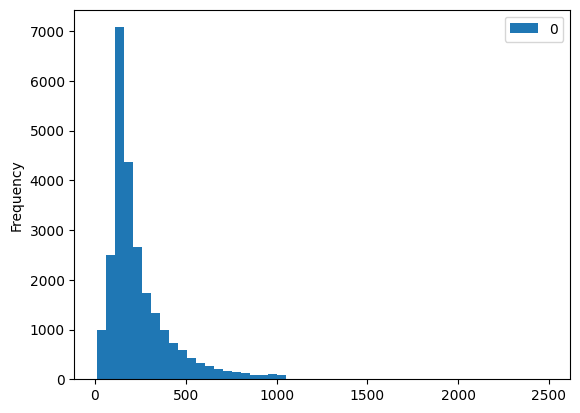

In [2]:
glove_path = '../glove.2024.dolma.300d/dolma_300_2024_1.2M.100_combined.txt'
embedding_dim = 300
vocab_size = 10000
index_from = 3

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

seq_len = [len(x) for x in x_train]
df = pd.DataFrame(seq_len)
df.plot(kind='hist', bins=50)
max_seq_len = df.quantile(0.95).values[0]

word_index = imdb.get_word_index()
reverse_index = {v + index_from: k for k, v in word_index.items()}
reverse_index[0] = "<PAD>"
reverse_index[1] = "<START>"
reverse_index[2] = "<UNK>"

In [3]:
def decode_review(seq):
    return " ".join(reverse_index.get(i, "?") for i in seq)

x_train_texts = [decode_review(x) for x in x_train]
x_test_texts  = [decode_review(x) for x in x_test]

x_train_pad = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=int(max_seq_len))
x_test_pad  = keras.preprocessing.sequence.pad_sequences(x_test,  maxlen=int(max_seq_len))

In [4]:
embeddings_index = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

word_index_glove = {k: (v + index_from) for k, v in imdb.get_word_index().items()}
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index_glove.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

coverage = np.count_nonzero(np.count_nonzero(embedding_matrix, axis=1)) / vocab_size

In [5]:
def build_model(embedding_layer):
    return keras.Sequential([
        embedding_layer,
        keras.layers.LSTM(128, unroll=True),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

emb_scratch = keras.layers.Embedding(
    vocab_size, 128, input_length=int(max_seq_len))

emb_glove_frozen = keras.layers.Embedding(
    vocab_size, embedding_dim,
    weights=[embedding_matrix],
    input_length=int(max_seq_len),
    trainable=False)

emb_glove_tuned = keras.layers.Embedding(
    vocab_size, embedding_dim,
    weights=[embedding_matrix],
    input_length=int(max_seq_len),
    trainable=True)

models = {
    'LSTM_scratch': build_model(emb_scratch),
    'GloVe_freeze': build_model(emb_glove_frozen),
    'GloVe_trainable': build_model(emb_glove_tuned)
}

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

/usr/local/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1777040848.998414    1291 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6900 MB memory:  -> device: 0, name: AMD Radeon RX 6600, pci bus id: 0000:0a:00.0


In [ ]:
results = {}
for name, model in models.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train_pad, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1
    )
    loss, acc = model.evaluate(x_test_pad, y_test, verbose=1)
    results[name] = {'test_loss': loss, 'test_accuracy': acc, 'history': history}


Epoch 1/10


2026-04-24 14:28:02.066901: I external/local_xla/xla/service/service.cc:163] XLA service 0x771c8000ab00 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2026-04-24 14:28:02.066913: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 6600, AMDGPU ISA version: gfx1030
2026-04-24 14:28:03.166617: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-24 14:32:20.174474: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-24 14:32:20.174509: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of th

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6736 - loss: 0.5851

In [ ]:
print(f"{name} → test acc: {acc:.4f}, test loss: {loss:.4f}")